In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_2d,net_2d,source_eval,error_general_2d,main
CUDA_LAUNCH_BLOCKING=1
def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1)
    # Apply the piecewise function
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values


cuda:1


In [2]:
import pickle
S_num_proce=np.load("./Noise/noise=10%/S_num_1600*2_10-30.npy")
with open("./Noise/noise=10%/cells_store_last.pkl", "rb") as f:
    cells_store=pickle.load(f)
x = np.linspace(0, 1, 301)
y = np.linspace(0, 1, 301)
X, Y = np.meshgrid(x, y,indexing='ij')
samples=np.vstack((X.ravel(),Y.ravel())).T
tau_x_min=0.0
tau_x_max=1.0
tau_y_min=0.0   
tau_y_max=1.0
# # Create data
# S_num_store=np.load("./results_ada/noise=5%_refine/S_num_store.npy")

In [ ]:
import visual
reload(visual)
import matplotlib.pyplot as plt
v=visual.GridMeshVisualizer() 
fig, axes = plt.subplots(1, 1, figsize=(6, 6))  # Draw one subplot for each stage
fig=v._plot_single_mesh(fig,axes,cells_store, S_num=None, points=samples,label=True)

In [5]:
fig.savefig("./Noise/noise=10%/mesh.pdf", dpi=300, bbox_inches='tight')

In [5]:
S_exact= f_circle(samples,0,1,0,1,center=[0.5,0.5],r=0.2).reshape(301,301)

In [6]:
g_S=np.load("./Noise/noise=10%/g_S.npy")
S_num_store=np.load("./Noise/noise=10%/S_num_store.npy")

DBSCAN eps = 0.016667 (5.000000 * h, h = 0.003333)
Number of detected clusters: 1
  CV of S_num: 0.262
Cluster 0: AR=1.01
  Res_Rect=0.092879 vs Res_Ellip=0.008873
  center=(0.5000, 0.4999)
  -> Decision: Ellipsoid (Sigmoid)


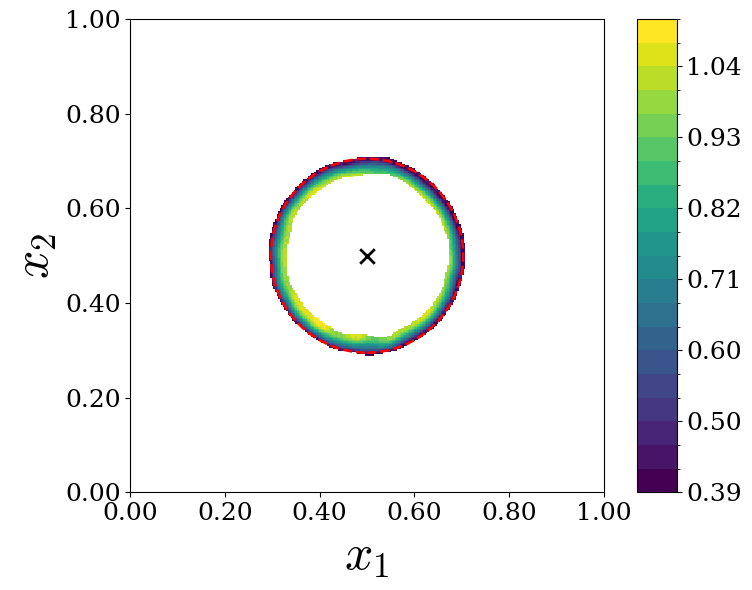

LaTeX table rows:
{\emph{Ex}} & Cluster $k$ & $\boldsymbol{c}_k$ & $r_k$ or $\boldsymbol{L}_k$ & $\mathcal{E}_{\mathrm{rect}}^{(k)}$ & $\mathcal{E}_{\mathrm{ellip}}^{(k)}$ & $\mathrm{AR}_k$ & $\mathrm{CV}_k$ & $\mathcal{T}_k$ & $\sigma_k$ \\
Ex 4.3 & 1 & (5.00e-01, 5.00e-01) & $\boldsymbol{L}$=(2.03e-01, 2.05e-01) & 0.0929 & 0.0089 & 1.01 & 0.262 & \textbf{Ellipsoid} & Sigmoid \\


['{\\emph{Ex}} & Cluster $k$ & $\\boldsymbol{c}_k$ & $r_k$ or $\\boldsymbol{L}_k$ & $\\mathcal{E}_{\\mathrm{rect}}^{(k)}$ & $\\mathcal{E}_{\\mathrm{ellip}}^{(k)}$ & $\\mathrm{AR}_k$ & $\\mathrm{CV}_k$ & $\\mathcal{T}_k$ & $\\sigma_k$ \\\\',
 'Ex 4.3 & 1 & (5.00e-01, 5.00e-01) & $\\boldsymbol{L}$=(2.03e-01, 2.05e-01) & 0.0929 & 0.0089 & 1.01 & 0.262 & \\textbf{Ellipsoid} & Sigmoid \\\\']

In [8]:
from importlib import reload
import bound_detect
reload(bound_detect)
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=5.0
mini_samples=20
para_abs=3
para_grad=3
results=bound_detect.detect_shape(g_S,X.T,Y.T,tau_x_min,tau_x_max,tau_y_min,tau_y_max,para_abs,para_grad,eps_cluster,mini_samples,S_num_store[-1],output_directory="./Noise/noise=10%/", output_filename="detect.pdf", eps_mode="grid_scaled")
print("LaTeX table rows:")
bound_detect.print_latex_result_rows(results, example_name="Ex 4.3", include_header=True)


Plot saved as ./Noise/noise=10%/ex4.3_S_num.pdf


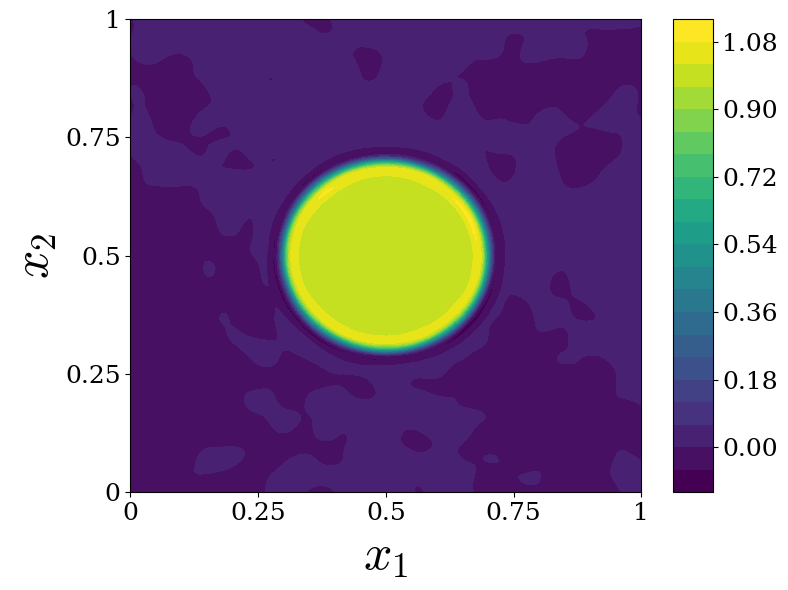

Plot saved as ./Noise/noise=10%/ex4.3_S_exact.pdf


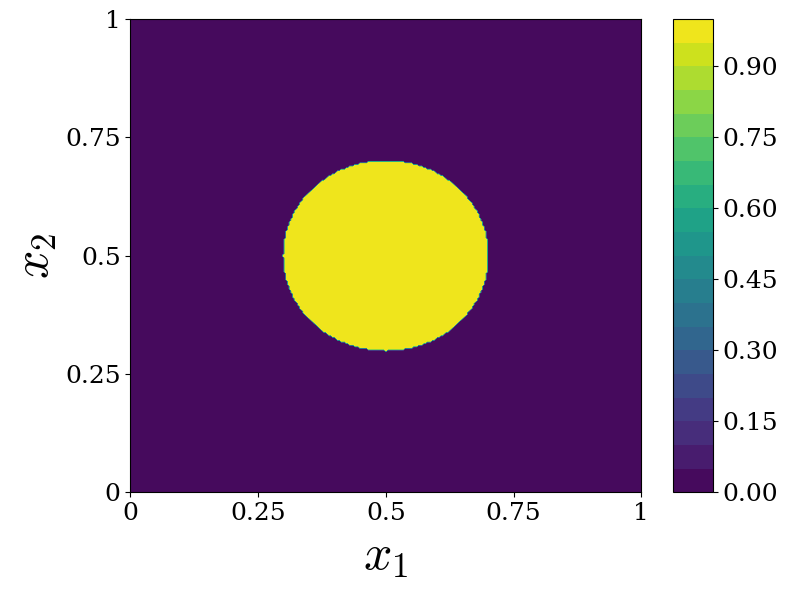

Plot saved as ./Noise/noise=10%/ex4.3_abs_S.pdf


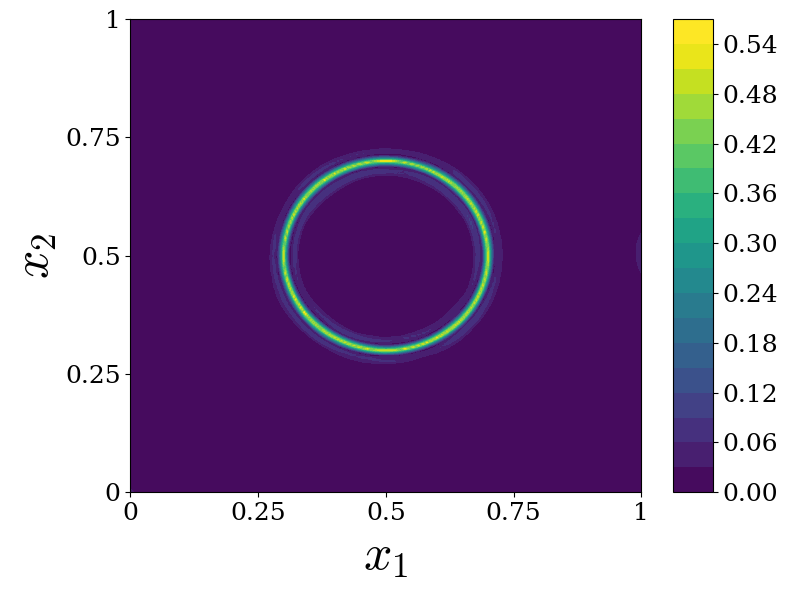

In [10]:
import visual
reload(visual)
visual.draw(X, Y, S_num_proce, tick_format="{:g}",x_ticks=[0, 0.25, 0.5, 0.75, 1], y_ticks=[0, 0.25, 0.5, 0.75, 1],output_directory="./Noise/noise=10%/", output_filename="S_num.pdf")
visual.draw(X, Y, S_exact,  tick_format="{:g}",x_ticks=[0, 0.25, 0.5, 0.75, 1], y_ticks=[0, 0.25, 0.5, 0.75, 1],output_directory="./Noise/noise=10%/", output_filename="S_exact.pdf")
visual.draw(X, Y, np.abs(S_num_proce - S_exact), tick_format="{:g}",x_ticks=[0, 0.25, 0.5, 0.75, 1], y_ticks=[0, 0.25, 0.5, 0.75, 1], output_directory="./Noise/noise=10%/", output_filename="abs_S.pdf")